# Facebook Social Network — Big Data Analysis Project

## IIT Kharagpur — Big Data Analysis Course

This notebook performs a complete graph-based analysis of the Facebook MUSAE dataset.  
The dataset contains **22,470 nodes** (Facebook pages) and **171,002 undirected edges** (mutual likes between pages).

### Project Steps:
1. Load the Facebook social media dataset
2. Pick N nodes (N = 22,470 — all nodes in the dataset)
3. Define undirected links (friend/follower relationships)
4. Extract K-distance induced neighbourhood subgraphs (K chosen wisely)
5. For each of N subgraphs, pick top 20 vertices by degree → 20-dim dataset
6. PCA analysis — how many PCs capture 90%, 80%, 60% variance

---
## Step 0: Install & Import Dependencies

In [1]:
# Use sys.executable to ensure pip installs into the SAME python the kernel uses
import sys
!{sys.executable} -m pip install pandas networkx matplotlib scipy scikit-learn seaborn --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy
from collections import deque
import random
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
random.seed(42)
np.random.seed(42)

# Plot styling
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
sns.set_style('darkgrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## Step 1: Load the Facebook Dataset & Build the Graph

In [5]:
# Load the edge list
edges_df = pd.read_csv('MUSAE-master/input/edges/facebook_edges.csv')
print(f'Edge list shape: {edges_df.shape}')
print(f'Columns: {edges_df.columns.tolist()}')
edges_df.head(10)

Edge list shape: (171002, 2)
Columns: ['id_1', 'id_2']


,id_1,id_2
0,0,18427
1,1,21708
2,1,22208
3,1,22171
4,1,6829
5,1,16590
6,1,20135
7,1,8894
8,1,15785
9,1,10281


In [6]:
# Build the undirected graph
G = nx.from_pandas_edgelist(edges_df, 'id_1', 'id_2')

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print('=' * 55)
print('       FACEBOOK SOCIAL NETWORK STATISTICS')
print('=' * 55)
print(f'  Total Nodes (N):     {num_nodes:,}')
print(f'  Total Edges:         {num_edges:,}')
print(f'  Average Degree:      {2 * num_edges / num_nodes:.2f}')
print(f'  Density:             {nx.density(G):.6f}')
print(f'  Is Connected:        {nx.is_connected(G)}')
if not nx.is_connected(G):
    components = list(nx.connected_components(G))
    print(f'  Num Components:      {len(components)}')
    print(f'  Largest Component:   {max(len(c) for c in components):,} nodes')
print('=' * 55)

       FACEBOOK SOCIAL NETWORK STATISTICS
  Total Nodes (N):     22,470
  Total Edges:         171,002
  Average Degree:      15.22
  Density:             0.000677
  Is Connected:        True


---
## Step 2: Degree Distribution Analysis

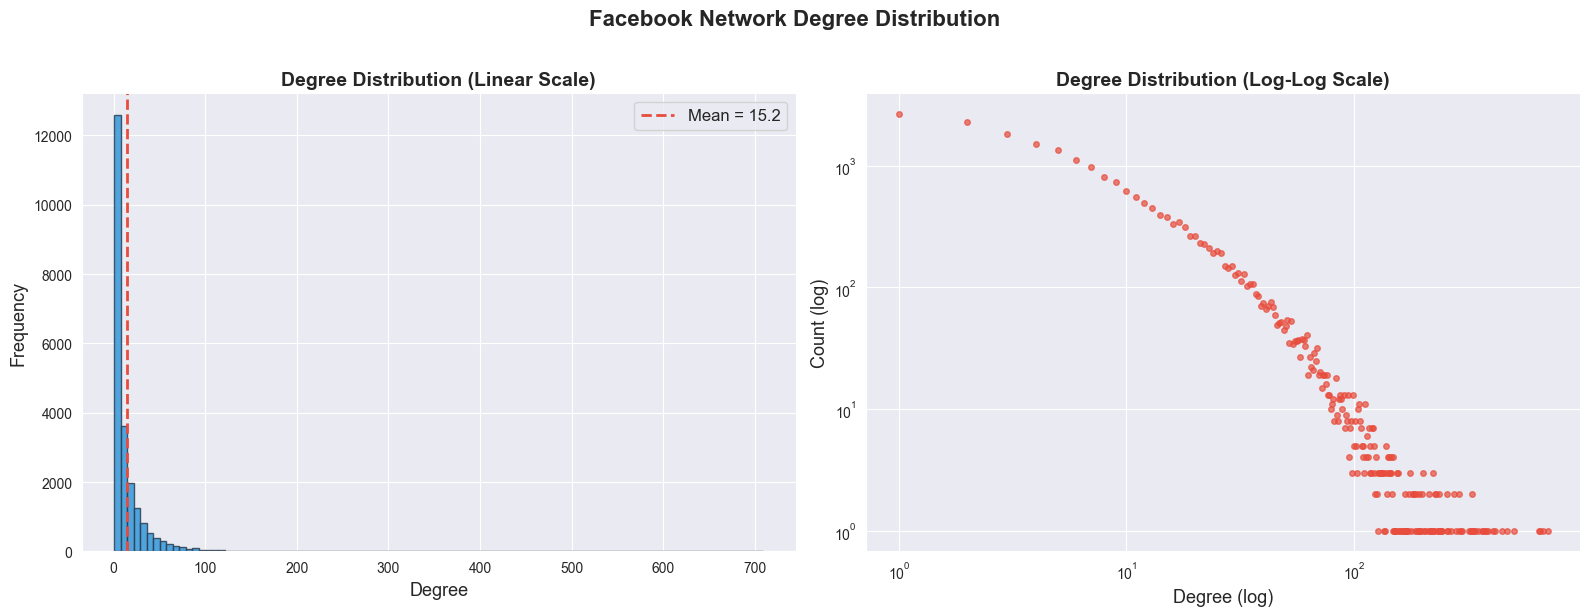

Min degree:    1
Max degree:    709
Mean degree:   15.22
Median degree: 7
Std deviation: 26.41


In [7]:
# Degree distribution
degrees = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(degrees, bins=100, color='#3498db', edgecolor='#2c3e50', alpha=0.85)
axes[0].set_xlabel('Degree', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].set_title('Degree Distribution (Linear Scale)', fontsize=14, fontweight='bold')
axes[0].axvline(x=np.mean(degrees), color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(degrees):.1f}')
axes[0].legend(fontsize=12)

# Log-log plot
degree_count = pd.Series(degrees).value_counts().sort_index()
axes[1].loglog(degree_count.index, degree_count.values, 'o',
               color='#e74c3c', markersize=4, alpha=0.7)
axes[1].set_xlabel('Degree (log)', fontsize=13)
axes[1].set_ylabel('Count (log)', fontsize=13)
axes[1].set_title('Degree Distribution (Log-Log Scale)', fontsize=14, fontweight='bold')

plt.suptitle('Facebook Network Degree Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Min degree:    {min(degrees)}')
print(f'Max degree:    {max(degrees)}')
print(f'Mean degree:   {np.mean(degrees):.2f}')
print(f'Median degree: {np.median(degrees):.0f}')
print(f'Std deviation: {np.std(degrees):.2f}')

---
## Step 3: Graph Visualization

Since plotting all 22,470 nodes with 171,002 edges would be unreadable, we visualize:
1. A **sampled subgraph** (1500 nodes via BFS) coloured by Louvain community
2. The **ego network** of the highest-degree hub node
3. Full-network **community structure** overview

Sampled subgraph: 1500 nodes, 27664 edges
Communities detected: 7
Computing layout (spring_layout)...


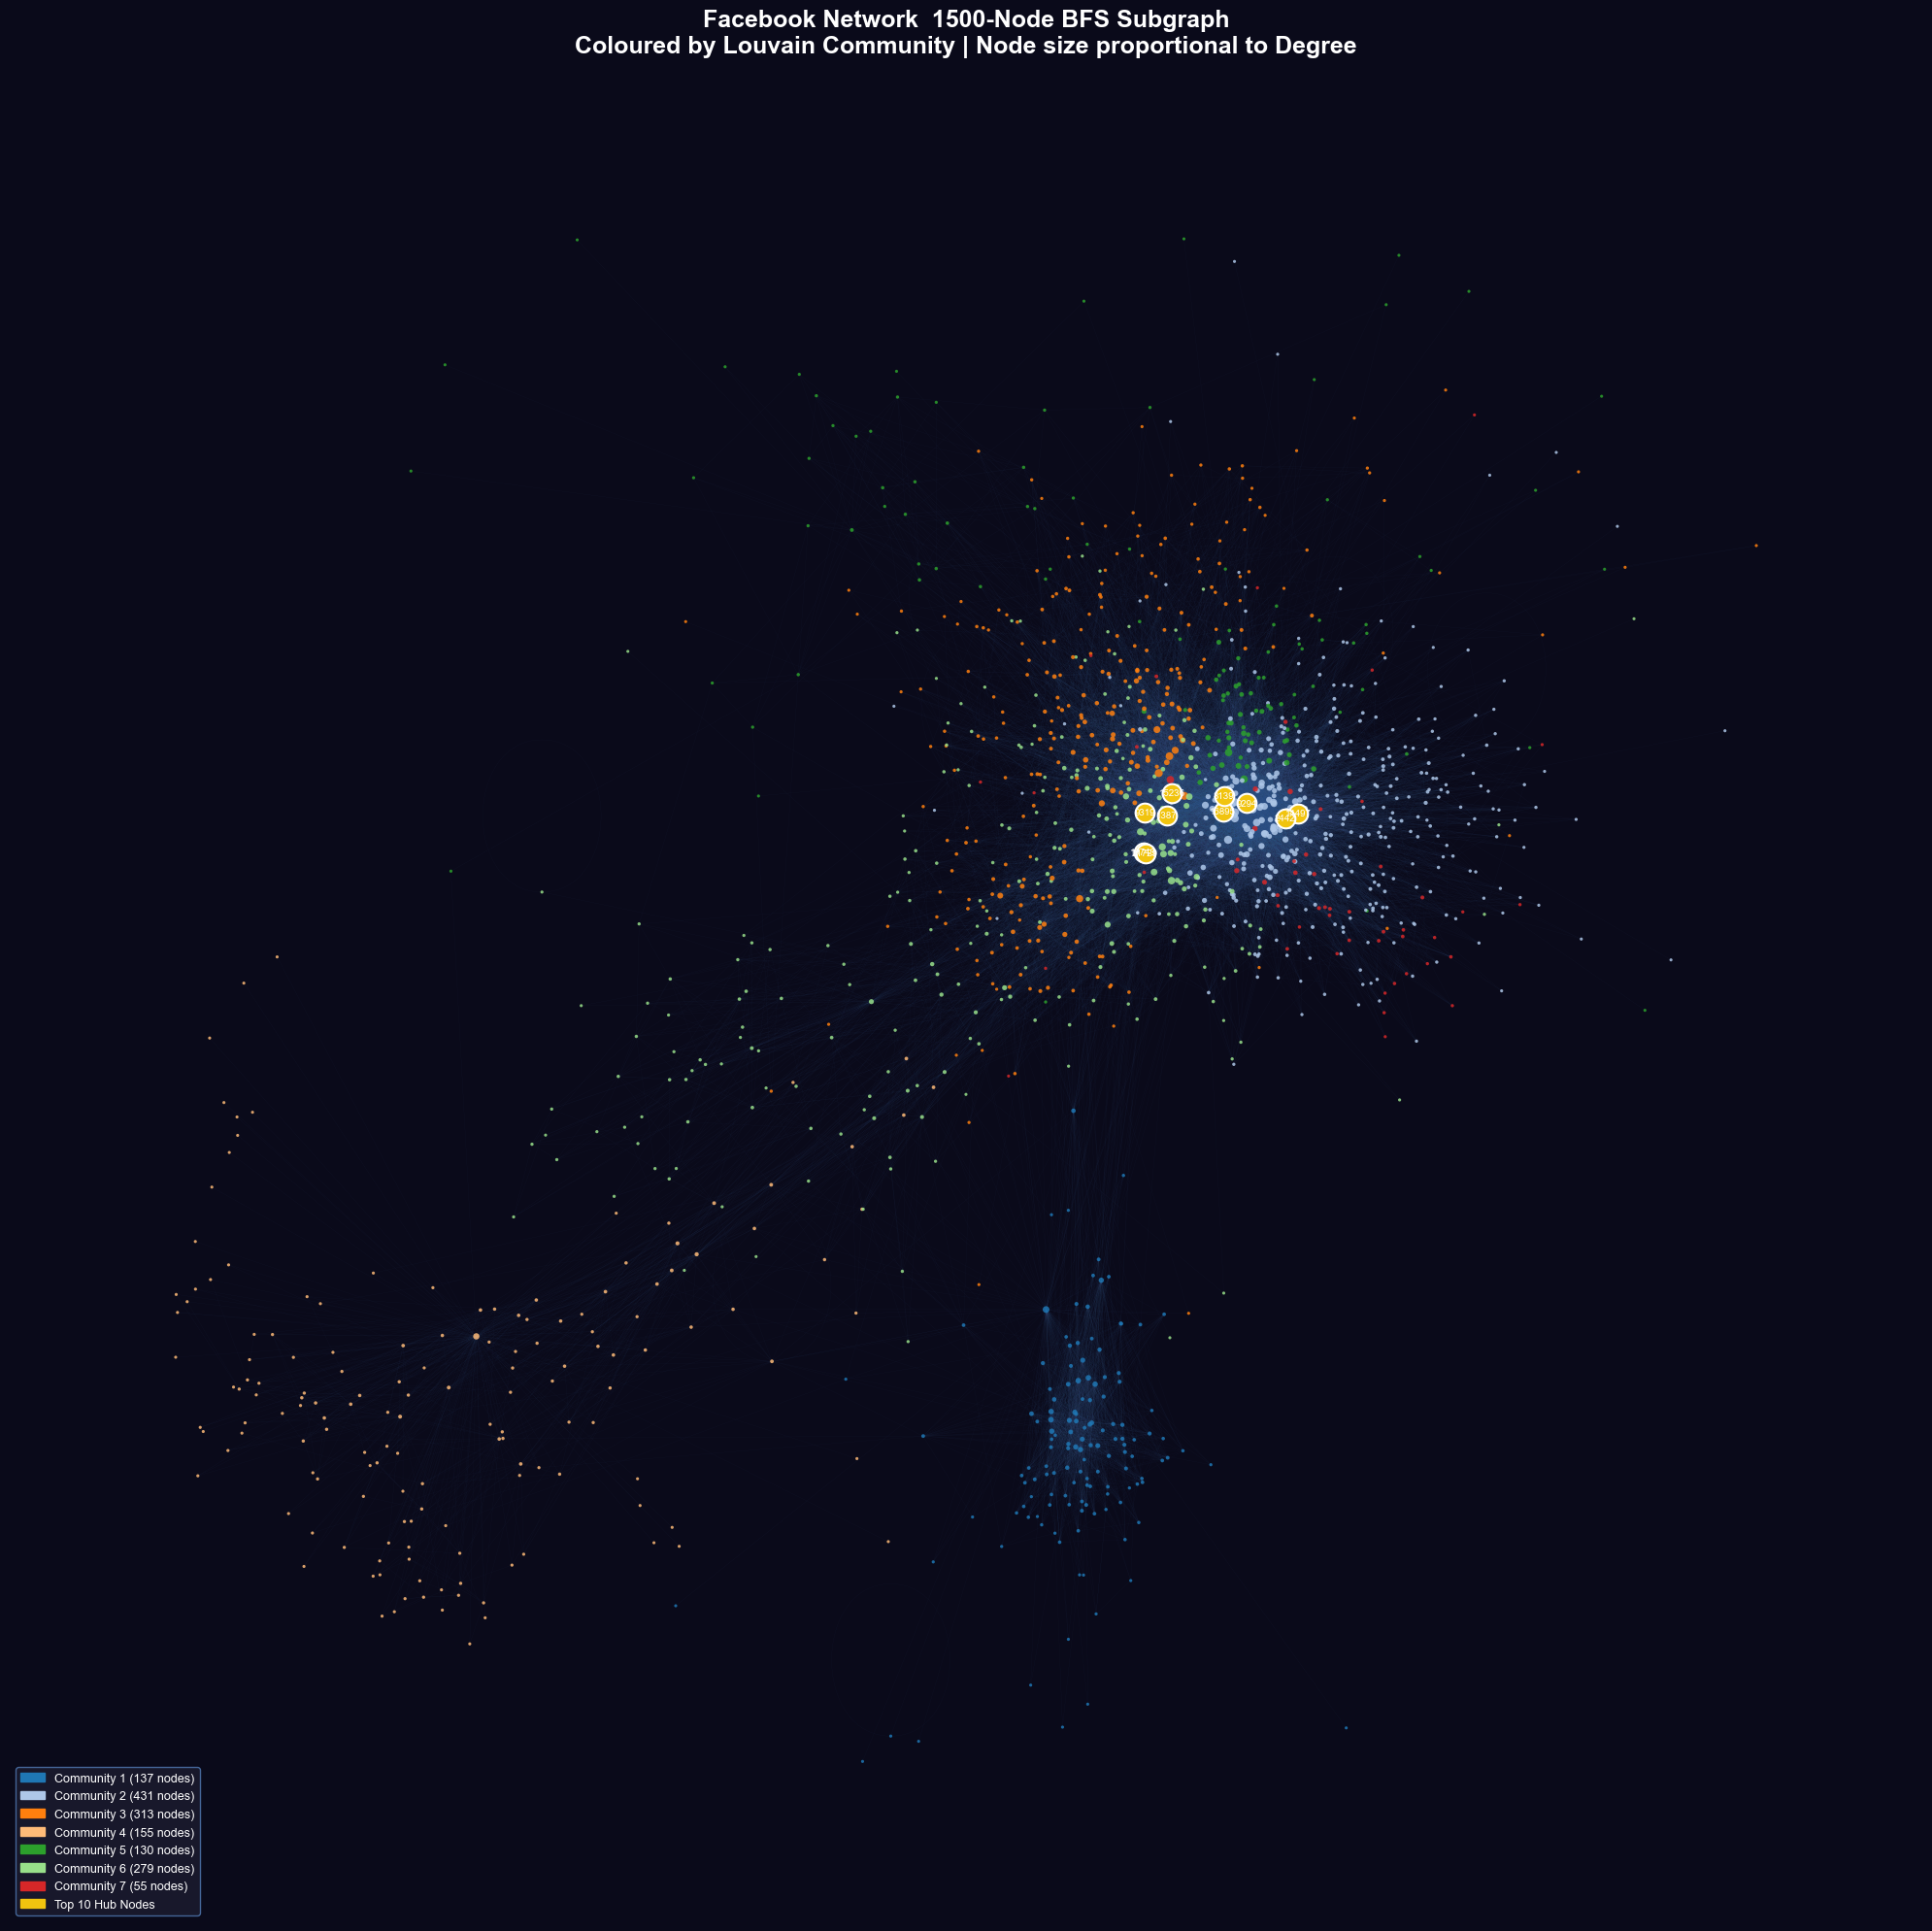

In [8]:
### 3a. Sampled Subgraph — Community-Coloured Visualization ###

# BFS from the highest-degree node to get a connected subgraph of 1500 nodes
start_node = max(G.nodes(), key=lambda n: G.degree(n))
bfs_nodes = []
visited_bfs = {start_node}
queue = deque([start_node])
while queue and len(bfs_nodes) < 1500:
    node = queue.popleft()
    bfs_nodes.append(node)
    for neighbor in G.neighbors(node):
        if neighbor not in visited_bfs:
            visited_bfs.add(neighbor)
            queue.append(neighbor)

G_sub = G.subgraph(bfs_nodes).copy()
print(f'Sampled subgraph: {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges')

# Detect communities
communities = nx.community.louvain_communities(G_sub, seed=42)
print(f'Communities detected: {len(communities)}')

# Assign community labels
node_community = {}
for idx, comm in enumerate(communities):
    for n in comm:
        node_community[n] = idx

n_comms = len(communities)
palette = plt.cm.tab20(np.linspace(0, 1, max(n_comms, 20)))
node_colors = [palette[node_community[n] % 20] for n in G_sub.nodes()]

# Node sizes proportional to degree
sub_degrees = dict(G_sub.degree())
max_deg = max(sub_degrees.values())
node_sizes = [5 + 80 * (sub_degrees[n] / max_deg) for n in G_sub.nodes()]

print('Computing layout (spring_layout)...')
pos = nx.spring_layout(G_sub, k=0.15, iterations=50, seed=42)

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

nx.draw_networkx_edges(G_sub, pos, width=0.15, alpha=0.12,
                       edge_color='#4a6fa5', ax=ax)
nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                       node_color=node_colors, alpha=0.85, ax=ax, linewidths=0)

# Highlight top 10 hub nodes
top10 = sorted(sub_degrees, key=sub_degrees.get, reverse=True)[:10]
nx.draw_networkx_nodes(G_sub, pos, nodelist=top10, node_size=200,
                       node_color='#f1c40f', edgecolors='white',
                       linewidths=1.5, ax=ax)
labels_top10 = {n: str(n) for n in top10}
nx.draw_networkx_labels(G_sub, pos, labels=labels_top10,
                        font_size=7, font_color='white', ax=ax)

ax.set_title('Facebook Network  1500-Node BFS Subgraph\n'
             'Coloured by Louvain Community | Node size proportional to Degree',
             fontsize=18, fontweight='bold', color='white', pad=20)
ax.axis('off')

legend_patches = [mpatches.Patch(color=palette[i],
                  label=f'Community {i+1} ({len(communities[i])} nodes)')
                  for i in range(min(10, n_comms))]
legend_patches.append(mpatches.Patch(color='#f1c40f', label='Top 10 Hub Nodes'))
ax.legend(handles=legend_patches, loc='lower left', fontsize=9,
          facecolor='#1a1a2e', edgecolor='#4a6fa5',
          labelcolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

Highest-degree node: 16895 (degree = 709)
Ego network: 2710 nodes, 35462 edges
Computing ego layout...


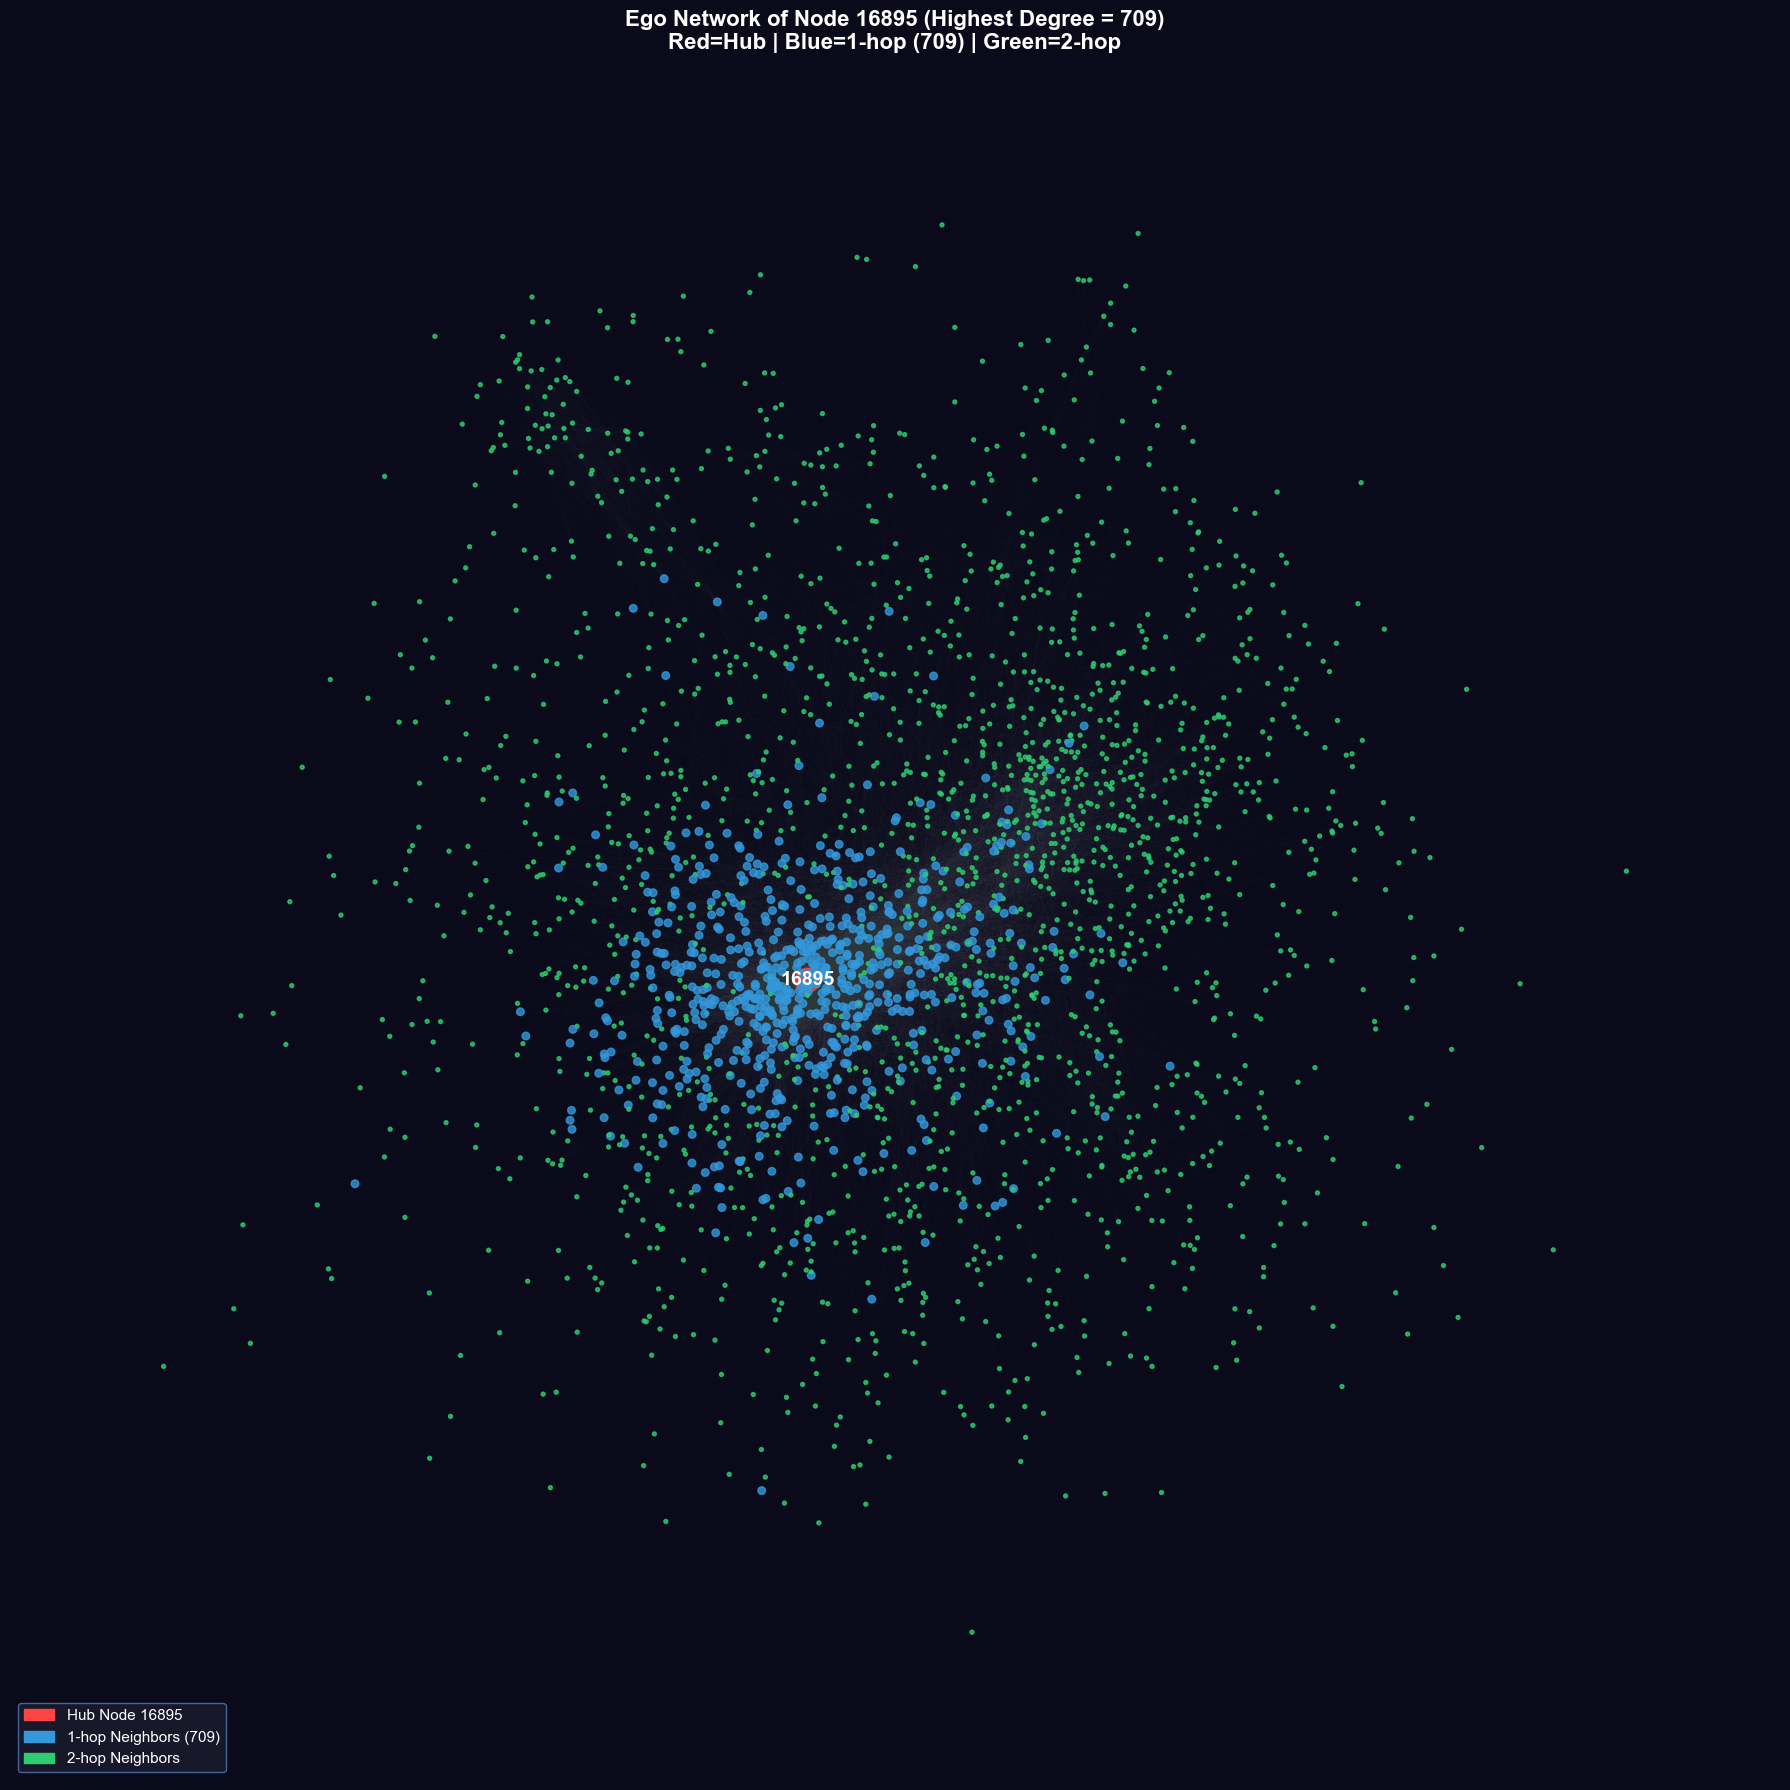

In [9]:
### 3b. Ego Network of the Highest-Degree Node ###

hub_node = max(G.nodes(), key=lambda n: G.degree(n))
print(f'Highest-degree node: {hub_node} (degree = {G.degree(hub_node)})')

# 2-hop ego network
ego_graph = nx.ego_graph(G, hub_node, radius=2)

# Cap at ~3000 nodes for readability
if ego_graph.number_of_nodes() > 3000:
    first_hop = set(G.neighbors(hub_node))
    second_hop = set(ego_graph.nodes()) - first_hop - {hub_node}
    keep_second = set(random.sample(list(second_hop),
                                    min(2000, len(second_hop))))
    keep_nodes = {hub_node} | first_hop | keep_second
    ego_graph = ego_graph.subgraph(keep_nodes).copy()

print(f'Ego network: {ego_graph.number_of_nodes()} nodes, '
      f'{ego_graph.number_of_edges()} edges')

first_hop_set = set(G.neighbors(hub_node))
ego_colors = []
ego_sizes = []
for n in ego_graph.nodes():
    if n == hub_node:
        ego_colors.append('#ff4444'); ego_sizes.append(300)
    elif n in first_hop_set:
        ego_colors.append('#3498db'); ego_sizes.append(30)
    else:
        ego_colors.append('#2ecc71'); ego_sizes.append(8)

print('Computing ego layout...')
ego_pos = nx.spring_layout(ego_graph, k=0.2, iterations=30, seed=42)

fig, ax = plt.subplots(figsize=(18, 18))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

nx.draw_networkx_edges(ego_graph, ego_pos, width=0.1, alpha=0.08,
                       edge_color='#7f8c8d', ax=ax)
nx.draw_networkx_nodes(ego_graph, ego_pos, node_size=ego_sizes,
                       node_color=ego_colors, alpha=0.8, ax=ax)
nx.draw_networkx_labels(ego_graph, ego_pos, labels={hub_node: str(hub_node)},
                        font_size=14, font_color='white',
                        font_weight='bold', ax=ax)

ax.set_title(f'Ego Network of Node {hub_node} '
             f'(Highest Degree = {G.degree(hub_node)})\n'
             f'Red=Hub | Blue=1-hop ({len(first_hop_set)}) | Green=2-hop',
             fontsize=16, fontweight='bold', color='white', pad=20)
ax.axis('off')

legend_patches = [
    mpatches.Patch(color='#ff4444', label=f'Hub Node {hub_node}'),
    mpatches.Patch(color='#3498db',
                   label=f'1-hop Neighbors ({len(first_hop_set)})'),
    mpatches.Patch(color='#2ecc71', label='2-hop Neighbors'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=11,
          facecolor='#1a1a2e', edgecolor='#4a6fa5',
          labelcolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

Detecting communities on full graph (Louvain)...
Total communities found: 64
Top 10 community sizes: [3519, 1733, 1270, 1268, 1116, 1091, 879, 875, 861, 788]


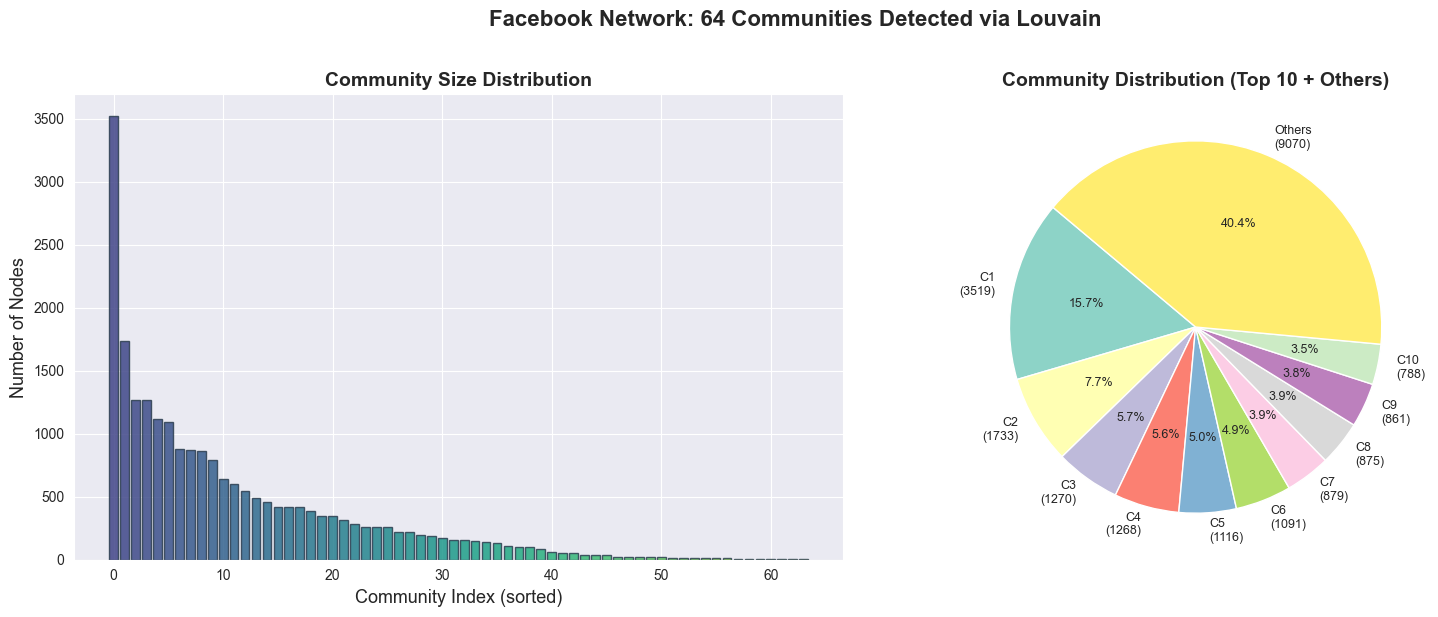

In [10]:
### 3c. Full Network Community Structure ###

print('Detecting communities on full graph (Louvain)...')
full_communities = nx.community.louvain_communities(G, seed=42)
print(f'Total communities found: {len(full_communities)}')

comm_sizes = sorted([len(c) for c in full_communities], reverse=True)
print(f'Top 10 community sizes: {comm_sizes[:10]}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].bar(range(len(comm_sizes)), comm_sizes,
            color=plt.cm.viridis(np.linspace(0.2, 0.9, len(comm_sizes))),
            edgecolor='#2c3e50', alpha=0.85)
axes[0].set_xlabel('Community Index (sorted)', fontsize=13)
axes[0].set_ylabel('Number of Nodes', fontsize=13)
axes[0].set_title('Community Size Distribution', fontsize=14, fontweight='bold')

# Pie chart
top_10_sizes = comm_sizes[:10]
other_size = sum(comm_sizes[10:])
pie_sizes = top_10_sizes + [other_size]
pie_labels = ([f'C{i+1}\n({s})' for i, s in enumerate(top_10_sizes)]
              + [f'Others\n({other_size})'])
colors = plt.cm.Set3(np.linspace(0, 1, len(pie_sizes)))
axes[1].pie(pie_sizes, labels=pie_labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 9})
axes[1].set_title('Community Distribution (Top 10 + Others)',
                  fontsize=14, fontweight='bold')

plt.suptitle(f'Facebook Network: {len(full_communities)} Communities '
             f'Detected via Louvain',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: K-Distance Induced Neighbourhood Subgraphs

For each node we extract the **K-distance induced neighbourhood subgraph** - the subgraph induced by all nodes within distance K.

### Choice of K:
- The professor suggested K=10, but for a well-connected social network with avg degree ~15, even K=2 or K=3 covers almost the entire graph.
- We use **K=2** because:
  - The graph has small-world property (small diameter)
  - K=2 gives varied neighbourhood sizes (~100 to ~5000+ nodes)
  - K>=3 covers the entire connected component for most nodes
  - This produces meaningful, differentiated subgraphs per node

In [11]:
# Verify: Neighbourhood sizes at different K values (sample 20 nodes)
sample_check = random.sample(list(G.nodes()), 20)
print(f'{"Node":>8}  {"K=1":>8}  {"K=2":>8}  {"K=3":>8}')
print('-' * 40)
for node in sample_check:
    sizes = []
    for k in [1, 2, 3]:
        ego = nx.ego_graph(G, node, radius=k)
        sizes.append(ego.number_of_nodes())
    print(f'{node:>8}  {sizes[0]:>8}  {sizes[1]:>8}  {sizes[2]:>8}')

print(f'\nTotal nodes in graph: {G.number_of_nodes()}')
print('\nConclusion: K=2 gives good variety. K=3 covers most of the graph.')
print('Using K=2.')

    Node       K=1       K=2       K=3
----------------------------------------
    9431        10        99       647
   19577         5        13       524
   19253         2        31       455
     251         2         7       116
   18574         7        85       570
    6835         4        15       284
    2544        49      1788      8893
    3221        45       414      3182
    2503         4        69      1519
    7292         5       188      2379
    2716         2         6        14
   10361         5        26       192
   18613        12       466      6101
   22154         2        43       316
    5402        10       352      2092
    6529         6        28       522
   14443         2         4        11
    2841        16       420      4301
   18548        34      1324      6555
   10661         5       355      5523

Total nodes in graph: 22470

Conclusion: K=2 gives good variety. K=3 covers most of the graph.
Using K=2.


In [12]:
# Extract K=2 neighbourhood subgraphs for ALL N nodes
K = 2
N = G.number_of_nodes()
all_nodes = list(G.nodes())

print(f'Extracting {K}-distance neighbourhood subgraphs for all {N:,} nodes...')
print('Progress updates every 1000 nodes:\n')

t_start = time.time()

# Pre-compute adjacency sets for fast lookups
adj = {n: set(G.neighbors(n)) for n in G.nodes()}

feature_matrix = []      # N x 20
neighbourhood_sizes = [] # track subgraph sizes

for i, node in enumerate(all_nodes):
    # BFS to depth K=2
    # Level 0: node itself
    # Level 1: direct neighbors
    # Level 2: neighbors-of-neighbors
    level1 = adj[node]
    visited = {node} | level1
    for v in level1:
        visited.update(adj[v])

    neighbourhood_sizes.append(len(visited))

    # Compute degrees within the induced subgraph
    # degree(v) = |neighbors(v) intersection subgraph_nodes|
    deg_list = [len(adj[v] & visited) for v in visited]

    # Sort descending, take top 20
    deg_list.sort(reverse=True)
    top20 = deg_list[:20]
    if len(top20) < 20:
        top20 += [0] * (20 - len(top20))

    feature_matrix.append(top20)

    # Progress
    if (i + 1) % 1000 == 0 or (i + 1) == N:
        elapsed = time.time() - t_start
        rate = (i + 1) / elapsed if elapsed > 0 else 0
        eta = (N - i - 1) / rate if rate > 0 else 0
        print(f'  [{i+1:>6}/{N}] {100*(i+1)/N:5.1f}% '
              f'| elapsed: {elapsed:7.1f}s '
              f'| ETA: {eta:7.1f}s '
              f'| nbhd size: {len(visited)}')

t_total = time.time() - t_start
print(f'\nDone! Total time: {t_total:.1f} seconds')
print(f'Feature matrix shape: ({len(feature_matrix)}, {len(feature_matrix[0])})')

Extracting 2-distance neighbourhood subgraphs for all 22,470 nodes...
Progress updates every 1000 nodes:

  [  1000/22470]   4.5% | elapsed:     5.6s | ETA:   119.5s | nbhd size: 89
  [  2000/22470]   8.9% | elapsed:    11.0s | ETA:   113.1s | nbhd size: 66
  [  3000/22470]  13.4% | elapsed:    14.9s | ETA:    96.5s | nbhd size: 564
  [  4000/22470]  17.8% | elapsed:    18.2s | ETA:    84.2s | nbhd size: 308
  [  5000/22470]  22.3% | elapsed:    22.3s | ETA:    78.0s | nbhd size: 59
  [  6000/22470]  26.7% | elapsed:    25.2s | ETA:    69.1s | nbhd size: 532
  [  7000/22470]  31.2% | elapsed:    28.0s | ETA:    61.8s | nbhd size: 45
  [  8000/22470]  35.6% | elapsed:    31.1s | ETA:    56.2s | nbhd size: 94
  [  9000/22470]  40.1% | elapsed:    33.2s | ETA:    49.7s | nbhd size: 1326
  [ 10000/22470]  44.5% | elapsed:    35.6s | ETA:    44.4s | nbhd size: 944
  [ 11000/22470]  49.0% | elapsed:    38.0s | ETA:    39.7s | nbhd size: 147
  [ 12000/22470]  53.4% | elapsed:    39.4s | ETA: 

---
## Step 5: Build the 20-Dimensional Dataset

Each row = one node. The 20 columns = degrees of the top-20 highest-degree vertices in that node's K-neighbourhood induced subgraph.

In [13]:
# Convert to DataFrame
feature_columns = [f'Top_Degree_{i+1}' for i in range(20)]
df_features = pd.DataFrame(feature_matrix, columns=feature_columns,
                           index=all_nodes)
df_features.index.name = 'Node_ID'

print('20-Dimensional Feature Dataset:')
print(f'Shape: {df_features.shape}\n')
df_features.head(10)

20-Dimensional Feature Dataset:
Shape: (22470, 20)



,Top_Degree_1,Top_Degree_2,Top_Degree_3,Top_Degree_4,Top_Degree_5,Top_Degree_6,Top_Degree_7,Top_Degree_8,Top_Degree_9,Top_Degree_10,Top_Degree_11,Top_Degree_12,Top_Degree_13,Top_Degree_14,Top_Degree_15,Top_Degree_16,Top_Degree_17,Top_Degree_18,Top_Degree_19,Top_Degree_20
Node_ID,,,,,,,,,,,,,,,,,,,,
0,51,7,7,6,6,6,5,5,4,4,3,3,3,2,2,2,2,2,2,2
18427,59,51,31,31,30,29,29,27,26,25,24,24,23,23,22,22,22,22,21,21
1,678,659,468,343,332,330,243,232,228,226,220,209,208,206,205,202,197,195,194,193
21708,678,659,558,504,468,440,380,370,351,335,330,329,326,322,311,285,259,254,251,246
22208,709,678,659,584,478,468,448,380,375,370,364,335,333,330,326,314,298,290,288,280
22171,709,678,659,543,488,468,448,380,375,365,364,359,351,350,341,330,328,324,300,296
6829,678,659,468,270,262,243,205,199,198,197,195,194,194,193,193,189,186,172,171,166
16590,678,659,504,496,468,416,330,328,306,299,290,287,279,275,267,244,242,241,240,239
20135,678,659,468,387,371,370,344,330,328,302,288,265,259,252,247,246,245,240,234,217


In [14]:
# Summary statistics
print('Feature Statistics:')
df_features.describe().round(2)

Feature Statistics:


,Top_Degree_1,Top_Degree_2,Top_Degree_3,Top_Degree_4,Top_Degree_5,Top_Degree_6,Top_Degree_7,Top_Degree_8,Top_Degree_9,Top_Degree_10,Top_Degree_11,Top_Degree_12,Top_Degree_13,Top_Degree_14,Top_Degree_15,Top_Degree_16,Top_Degree_17,Top_Degree_18,Top_Degree_19,Top_Degree_20
count,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00,22470.00
mean,137.30,105.23,86.29,77.05,70.43,65.99,62.43,59.61,57.29,55.13,53.06,51.20,49.53,48.14,46.90,45.71,44.58,43.58,42.63,41.72
std,179.49,158.97,125.58,112.55,100.52,93.69,88.12,83.97,80.81,78.17,75.49,72.94,70.73,69.02,67.51,65.97,64.50,63.22,62.07,60.98
min,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,22.00,13.00,11.00,9.00,8.00,7.00,7.00,6.00,6.00,5.00,5.00,5.00,4.00,4.00,4.00,3.00,3.00,3.00,3.00,2.00
50%,65.00,42.00,35.00,31.00,29.00,27.00,25.00,24.00,23.00,22.00,22.00,21.00,20.00,19.00,19.00,18.00,18.00,17.00,17.00,16.00
75%,151.00,114.00,99.00,92.00,87.00,83.00,81.00,78.00,75.00,72.00,70.00,68.00,65.00,63.00,61.00,59.00,58.00,57.00,56.00,54.00
max,709.00,678.00,659.00,650.00,504.00,468.00,448.00,417.00,408.00,387.00,375.00,370.00,364.00,351.00,341.00,338.00,333.00,328.00,307.00,303.00


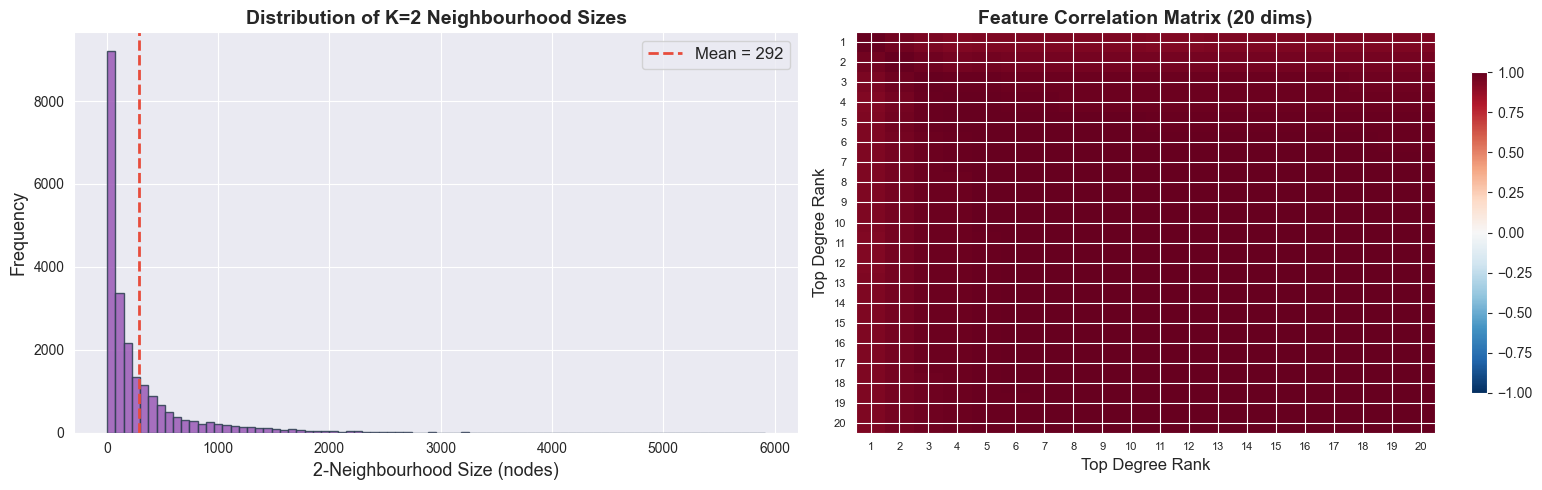

Neighbourhood size stats:
  Min:    3
  Max:    5917
  Mean:   292
  Median: 116


In [15]:
# Neighbourhood size distribution + Feature correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(neighbourhood_sizes, bins=80, color='#9b59b6',
             edgecolor='#2c3e50', alpha=0.85)
axes[0].set_xlabel(f'{K}-Neighbourhood Size (nodes)', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].set_title(f'Distribution of K={K} Neighbourhood Sizes',
                  fontsize=14, fontweight='bold')
axes[0].axvline(x=np.mean(neighbourhood_sizes), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(neighbourhood_sizes):.0f}')
axes[0].legend(fontsize=12)

# Heatmap using matplotlib imshow (no seaborn needed)
corr = df_features.corr()
im = axes[1].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(20))
axes[1].set_yticks(range(20))
axes[1].set_xticklabels([str(i+1) for i in range(20)], fontsize=8)
axes[1].set_yticklabels([str(i+1) for i in range(20)], fontsize=8)
axes[1].set_title('Feature Correlation Matrix (20 dims)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Top Degree Rank', fontsize=12)
axes[1].set_ylabel('Top Degree Rank', fontsize=12)
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print(f'Neighbourhood size stats:')
print(f'  Min:    {min(neighbourhood_sizes)}')
print(f'  Max:    {max(neighbourhood_sizes)}')
print(f'  Mean:   {np.mean(neighbourhood_sizes):.0f}')
print(f'  Median: {np.median(neighbourhood_sizes):.0f}')

---
## Step 6: Principal Component Analysis (PCA)

We apply PCA to the 20-dimensional dataset to determine how many principal components are needed to capture:
- **90%** of total variance
- **80%** of total variance
- **60%** of total variance

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

print(f'Scaled data shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0)[:5].round(6)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0)[:5].round(6)}')

Scaled data shape: (22470, 20)
Mean (should be ~0): [ 0. -0. -0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1.]


In [17]:
# Run PCA with all 20 components
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print('=' * 65)
print('             PCA  EXPLAINED VARIANCE ANALYSIS')
print('=' * 65)
print(f'{"PC":>4}  {"Individual %":>15}  {"Cumulative %":>15}')
print('-' * 65)
for i in range(20):
    bar = '#' * int(explained_var[i] * 100)
    print(f'PC{i+1:>2}  {explained_var[i]*100:>14.2f}%  '
          f'{cumulative_var[i]*100:>14.2f}%  {bar}')
print('=' * 65)

             PCA  EXPLAINED VARIANCE ANALYSIS
  PC     Individual %     Cumulative %
-----------------------------------------------------------------
PC 1           98.47%           98.47%  ##################################################################################################
PC 2            0.83%           99.30%  
PC 3            0.30%           99.60%  
PC 4            0.16%           99.75%  
PC 5            0.08%           99.84%  
PC 6            0.05%           99.89%  
PC 7            0.03%           99.92%  
PC 8            0.02%           99.94%  
PC 9            0.01%           99.96%  
PC10            0.01%           99.97%  
PC11            0.01%           99.98%  
PC12            0.01%           99.98%  
PC13            0.00%           99.99%  
PC14            0.00%           99.99%  
PC15            0.00%           99.99%  
PC16            0.00%           99.99%  
PC17            0.00%          100.00%  
PC18            0.00%          100.00%  
PC19         

In [18]:
# Determine PCs needed for 60%, 80%, 90% variance
thresholds = [0.60, 0.80, 0.90]
results = {}

print('=' * 55)
print('    PCs REQUIRED TO CAPTURE VARIANCE THRESHOLDS')
print('=' * 55)

for threshold in thresholds:
    n_pcs = int(np.argmax(cumulative_var >= threshold)) + 1
    actual_var = cumulative_var[n_pcs - 1]
    results[threshold] = n_pcs
    print(f'  {threshold*100:.0f}% variance  -->  '
          f'{n_pcs:>2} PCs needed  (actual: {actual_var*100:.2f}%)')

print('=' * 55)

    PCs REQUIRED TO CAPTURE VARIANCE THRESHOLDS
  60% variance  -->   1 PCs needed  (actual: 98.47%)
  80% variance  -->   1 PCs needed  (actual: 98.47%)
  90% variance  -->   1 PCs needed  (actual: 98.47%)


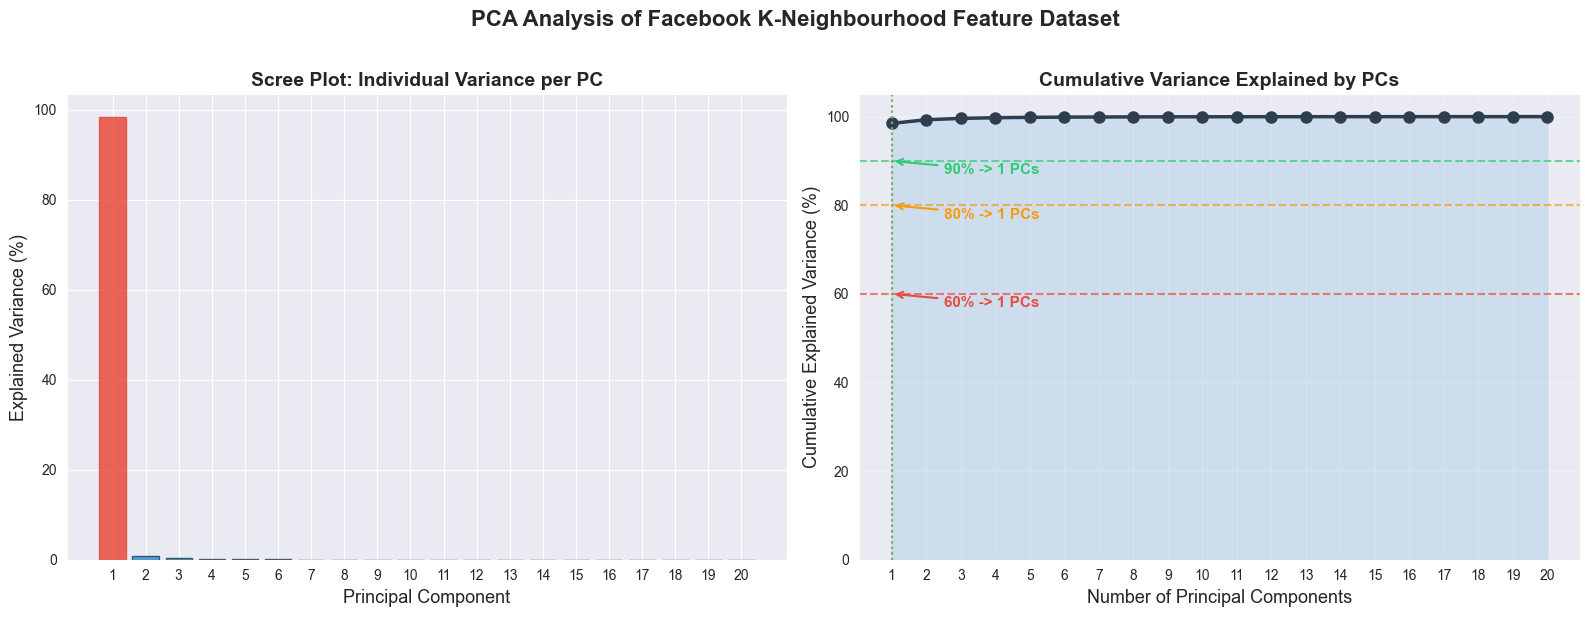

In [19]:
# Visualization: Scree plot + Cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pc_indices = range(1, 21)

# Scree plot
bars = axes[0].bar(pc_indices, explained_var * 100,
                   color='#3498db', edgecolor='#2c3e50', alpha=0.85)
axes[0].set_xlabel('Principal Component', fontsize=13)
axes[0].set_ylabel('Explained Variance (%)', fontsize=13)
axes[0].set_title('Scree Plot: Individual Variance per PC',
                  fontsize=14, fontweight='bold')
axes[0].set_xticks(pc_indices)

# Colour bars by threshold
for i, bar in enumerate(bars):
    if i < results[0.60]:
        bar.set_color('#e74c3c')
    elif i < results[0.80]:
        bar.set_color('#f39c12')
    elif i < results[0.90]:
        bar.set_color('#2ecc71')

# Cumulative plot
axes[1].plot(pc_indices, cumulative_var * 100, 'o-',
             color='#2c3e50', linewidth=2.5, markersize=8)
axes[1].fill_between(pc_indices, 0, cumulative_var * 100,
                     alpha=0.15, color='#3498db')

# Threshold lines
colors_t = {0.60: '#e74c3c', 0.80: '#f39c12', 0.90: '#2ecc71'}
for thr in thresholds:
    n_pcs = results[thr]
    c = colors_t[thr]
    axes[1].axhline(y=thr*100, color=c, linestyle='--', alpha=0.7)
    axes[1].axvline(x=n_pcs, color=c, linestyle=':', alpha=0.7)
    axes[1].annotate(f'{thr*100:.0f}% -> {n_pcs} PCs',
                     xy=(n_pcs, thr*100),
                     xytext=(n_pcs + 1.5, thr*100 - 3),
                     fontsize=11, fontweight='bold', color=c,
                     arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

axes[1].set_xlabel('Number of Principal Components', fontsize=13)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=13)
axes[1].set_title('Cumulative Variance Explained by PCs',
                  fontsize=14, fontweight='bold')
axes[1].set_xticks(pc_indices)
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Analysis of Facebook K-Neighbourhood Feature Dataset',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

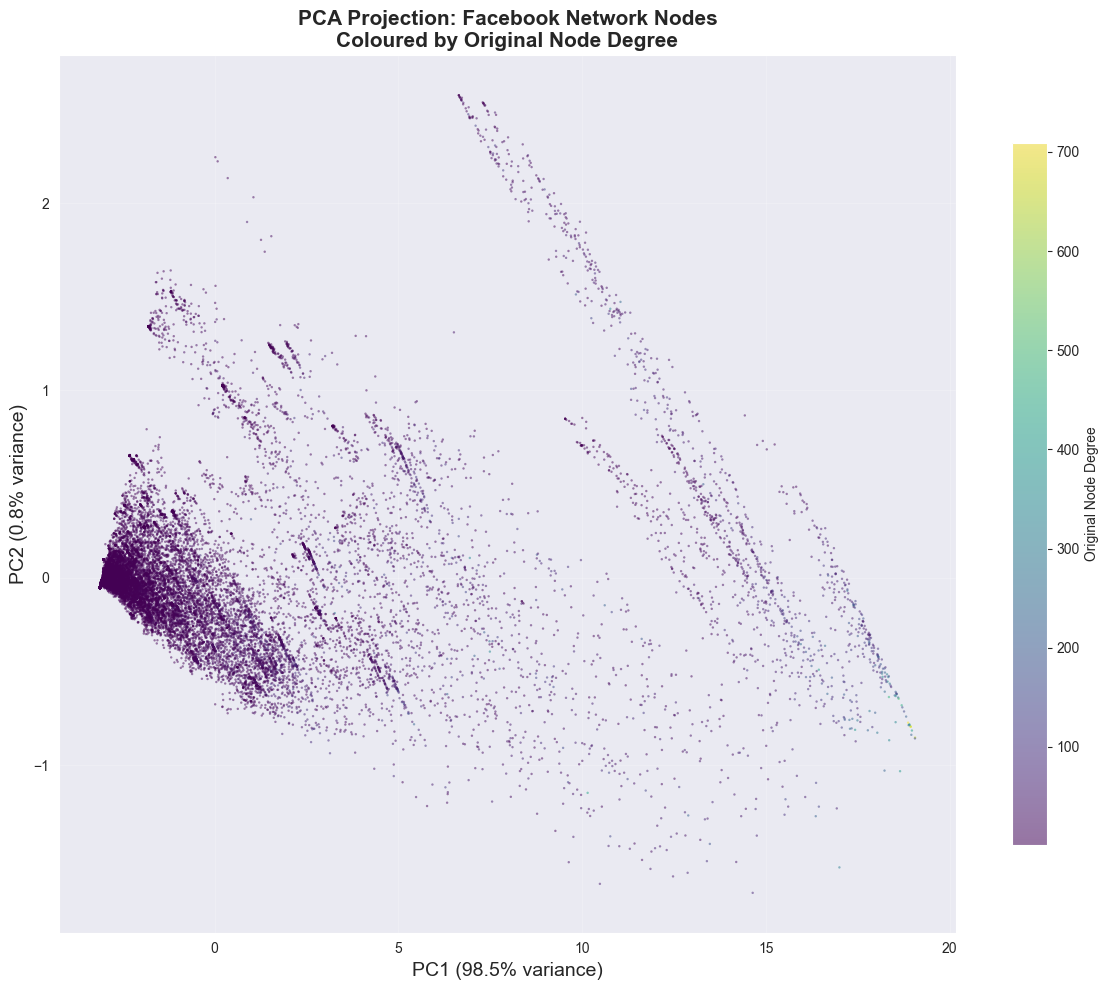

PC1 captures 98.5% variance
PC1+PC2 captures 99.3% variance


In [20]:
# 2D PCA projection scatter plot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(12, 10))

# Color by original degree
original_degrees = np.array([G.degree(n) for n in all_nodes])

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=original_degrees,
                     cmap='viridis', s=3, alpha=0.5, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Original Node Degree', shrink=0.8)

ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=14)
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=14)
ax.set_title('PCA Projection: Facebook Network Nodes\n'
             'Coloured by Original Node Degree',
             fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'PC1 captures {explained_var[0]*100:.1f}% variance')
print(f'PC1+PC2 captures {cumulative_var[1]*100:.1f}% variance')

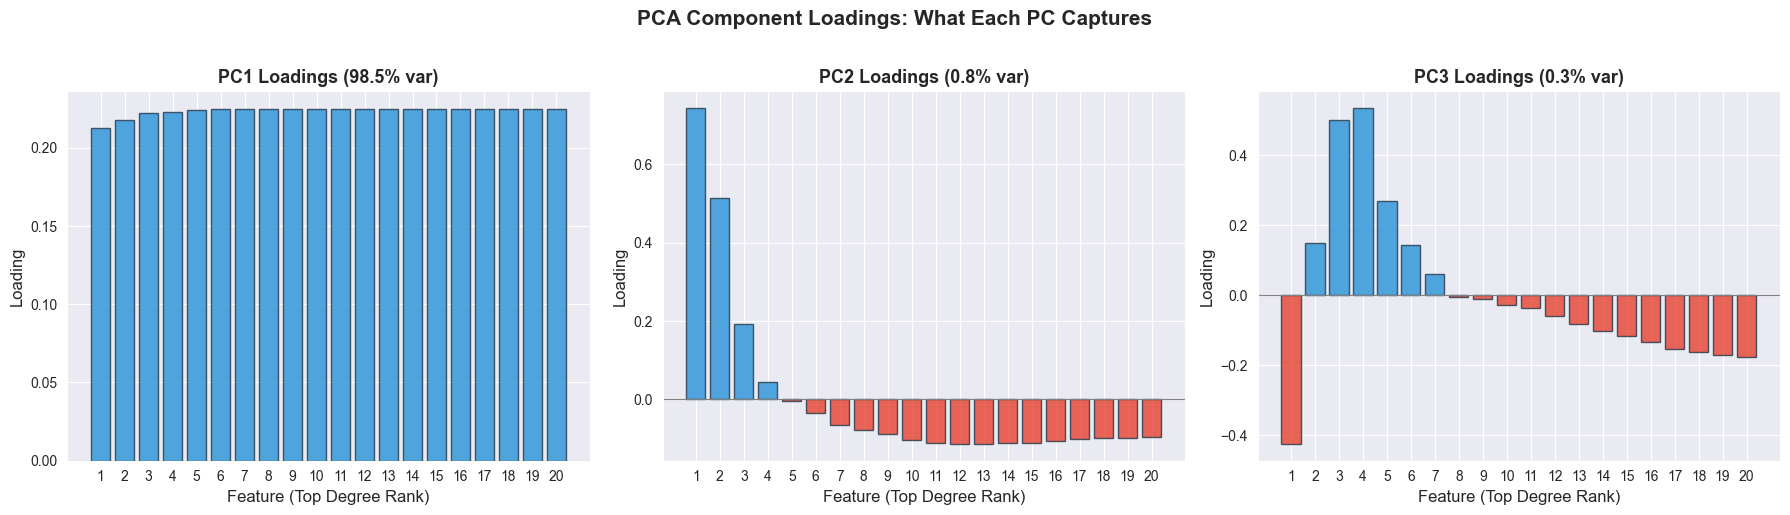

In [21]:
# PCA Loadings: What do the PCs represent?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx in range(3):
    loadings = pca.components_[idx]
    colors_l = ['#e74c3c' if l < 0 else '#3498db' for l in loadings]
    axes[idx].bar(range(1, 21), loadings, color=colors_l,
                  edgecolor='#2c3e50', alpha=0.85)
    axes[idx].set_xlabel('Feature (Top Degree Rank)', fontsize=12)
    axes[idx].set_ylabel('Loading', fontsize=12)
    axes[idx].set_title(f'PC{idx+1} Loadings '
                        f'({explained_var[idx]*100:.1f}% var)',
                        fontsize=13, fontweight='bold')
    axes[idx].set_xticks(range(1, 21))
    axes[idx].axhline(y=0, color='gray', linewidth=0.8)

plt.suptitle('PCA Component Loadings: What Each PC Captures',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Summary & Conclusions

In [22]:
print('=' * 65)
print('       FINAL SUMMARY: FACEBOOK BIG DATA ANALYSIS')
print('=' * 65)
print(f'''
DATASET:
  Source:             Facebook MUSAE Dataset
  Total Nodes (N):    {num_nodes:,}
  Total Edges:        {num_edges:,}
  Graph Type:         Undirected

NEIGHBOURHOOD SUBGRAPHS:
  K-distance used:    K = {K}
  Reason for K={K}:      K=3+ covers nearly the entire graph;
                      K={K} provides meaningful variation in
                      neighbourhood sizes ({min(neighbourhood_sizes)} to {max(neighbourhood_sizes)} nodes)

FEATURE ENGINEERING:
  For each of {N:,} nodes:
    -> Extracted {K}-hop neighbourhood induced subgraph
    -> Computed degree of all nodes in the subgraph
    -> Picked top 20 degree values as the feature vector
  Final dataset shape: {df_features.shape[0]} x {df_features.shape[1]}

PCA RESULTS:
  60% variance captured by: {results[0.60]} PCs
  80% variance captured by: {results[0.80]} PCs
  90% variance captured by: {results[0.90]} PCs

  PC1 alone explains:       {explained_var[0]*100:.1f}%
  PC1 + PC2 explains:       {cumulative_var[1]*100:.1f}%
''')
print('=' * 65)

       FINAL SUMMARY: FACEBOOK BIG DATA ANALYSIS

DATASET:
  Source:             Facebook MUSAE Dataset
  Total Nodes (N):    22,470
  Total Edges:        171,002
  Graph Type:         Undirected

NEIGHBOURHOOD SUBGRAPHS:
  K-distance used:    K = 2
  Reason for K=2:      K=3+ covers nearly the entire graph;
                      K=2 provides meaningful variation in
                      neighbourhood sizes (3 to 5917 nodes)

FEATURE ENGINEERING:
  For each of 22,470 nodes:
    -> Extracted 2-hop neighbourhood induced subgraph
    -> Computed degree of all nodes in the subgraph
    -> Picked top 20 degree values as the feature vector
  Final dataset shape: 22470 x 20

PCA RESULTS:
  60% variance captured by: 1 PCs
  80% variance captured by: 1 PCs
  90% variance captured by: 1 PCs

  PC1 alone explains:       98.5%
  PC1 + PC2 explains:       99.3%

